## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:**

Se requiere implementar un sistema de atención al cliente para una tienda que integra tres estructuras de datos:

1. Una **cola (FIFO)** con los clientes que esperan ser atendidos.
2. Una **pila (LIFO)** con el historial de las últimas atenciones, que permite deshacer la más reciente.
3. Una **lista doblemente enlazada** con el catálogo de productos, que permite agregar, buscar, eliminar y recorrer en ambos sentidos sin necesidad de reorganizar todo el inventario.

Al atender a un cliente este se retira de la cola y se apila en el historial; si la atención se deshace, el cliente vuelve al frente de la cola. Se debe justificar la elección de cada estructura, definir requerimientos e historias de usuario, modelar el comportamiento con diagramas, analizar la complejidad de las operaciones, implementar el código funcional y validarlo con pruebas (incluyendo pruebas de desempeño empírico).


In [1]:
# @title Ingrese datos
nombre_estudiante = "" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

La tienda necesita un pequeño sistema para controlar la atención de sus clientes, registrar el historial de operaciones realizadas y administrar su catálogo de productos. Para esto se utilizan tres estructuras de datos distintas, cada una elegida según el comportamiento real de la parte del problema que resuelve:

- **Cola (FIFO):** administra a los clientes que esperan ser atendidos, respetando el orden de llegada.
- **Pila (LIFO):** guarda el historial de las últimas atenciones realizadas, permitiendo consultar o deshacer la más reciente de forma inmediata.
- **Lista doblemente enlazada:** administra el catálogo de productos, permitiendo recorrerlo en ambos sentidos y modificarlo sin reorganizar todo el inventario.

Las tres estructuras trabajan de forma integrada: por ejemplo, cuando se atiende a un cliente, este se retira de la cola y se apila en el historial; y si esa atención se deshace, el cliente regresa al frente de la cola.

## 2) Requerimientos **[2 pts]**

### Cola de clientes

**Funcionales**
- RF1: registrar una cantidad inicial `n` de clientes al arrancar.
- RF2: agregar un nuevo cliente al final de la cola en cualquier momento.
- RF3: atender al cliente del frente de la cola, retirándolo de la espera.
- RF4: mostrar los clientes que siguen esperando, en orden.

**No funcionales**
- RNF1: agregar y atender deben ser O(1).
- RNF2: informar cuando se intenta atender y la cola está vacía.

### Pila de historial

**Funcionales**
- RF5: apilar automáticamente cada cliente que sea atendido.
- RF6: mostrar el último cliente atendido.
- RF7: deshacer la última atención, regresando al cliente al frente de la cola.

**No funcionales**
- RNF3: apilar, desapilar y consultar el tope deben ser O(1).
- RNF4: informar cuando se intenta consultar o deshacer con el historial vacío.

### Lista doblemente enlazada de productos

**Funcionales**
- RF8: agregar un producto (código, nombre, precio) al final de la lista.
- RF9: mostrar todos los productos de principio a fin y de fin a principio.
- RF10: buscar un producto por su código.
- RF11: eliminar un producto por su código, reconectando los nodos vecinos.
- RF12: no permitir dos productos con el mismo código.

**No funcionales**
- RNF5: recorrer, buscar y eliminar deben ser O(n); agregar debe ser O(1).
- RNF6: informar cuando una búsqueda o eliminación no encuentra el código solicitado.

### Comunes a todo el sistema
- RNF7: interacción mediante un menú de consola simple y claro.
- RNF8: código organizado de forma modular, separando cada estructura de datos del menú de interacción.
- RNF9: validar las entradas del usuario sin detener el programa abruptamente.

## 3) Historias de usuario **[2 pts]**

### Cola de clientes

**HU1 — Agregar cliente a la cola.** Como encargado, quiero agregar un nuevo cliente a la fila, para que sea atendido en su turno.
*Aceptación:* el cliente queda al final de la cola.

**HU2 — Atender al siguiente cliente.** Como encargado, quiero atender al cliente del frente, para respetar el orden de llegada.
*Aceptación:* se retira del frente de la cola y queda registrado en el historial; si la cola está vacía, se avisa.

**HU3 — Ver clientes en espera.** Como encargado, quiero ver quiénes siguen esperando, para saber cuántos faltan.
*Aceptación:* se listan en el orden en que serán atendidos.

### Pila de historial

**HU4 — Ver el último atendido.** Como encargado, quiero consultar quién fue el último cliente atendido, para tener claridad de la operación más reciente.
*Aceptación:* se muestra el cliente en el tope sin retirarlo; si está vacío, se avisa.

**HU5 — Deshacer la última atención.** Como encargado, quiero deshacer la última atención, para corregir un error.
*Aceptación:* el cliente se retira del tope y regresa al frente de la cola; si el historial está vacío, se avisa.

### Lista de catálogo

**HU6 — Agregar producto.** Como administrador, quiero agregar un producto nuevo al catálogo, para mantener el inventario actualizado.
*Aceptación:* queda al final de la lista; se rechaza si el código ya existe.

**HU7 — Buscar producto por código.** Como administrador, quiero buscar un producto por su código, para conocer su nombre y precio.
*Aceptación:* muestra el producto si existe, o un aviso si no.

**HU8 — Eliminar producto por código.** Como administrador, quiero eliminar un producto del catálogo, para sacar lo que ya no se vende.
*Aceptación:* el nodo se elimina reconectando sus vecinos; si no existe, se avisa el error.

## 4) Diagramas de flujo **[5 pts]**

### Cola de clientes

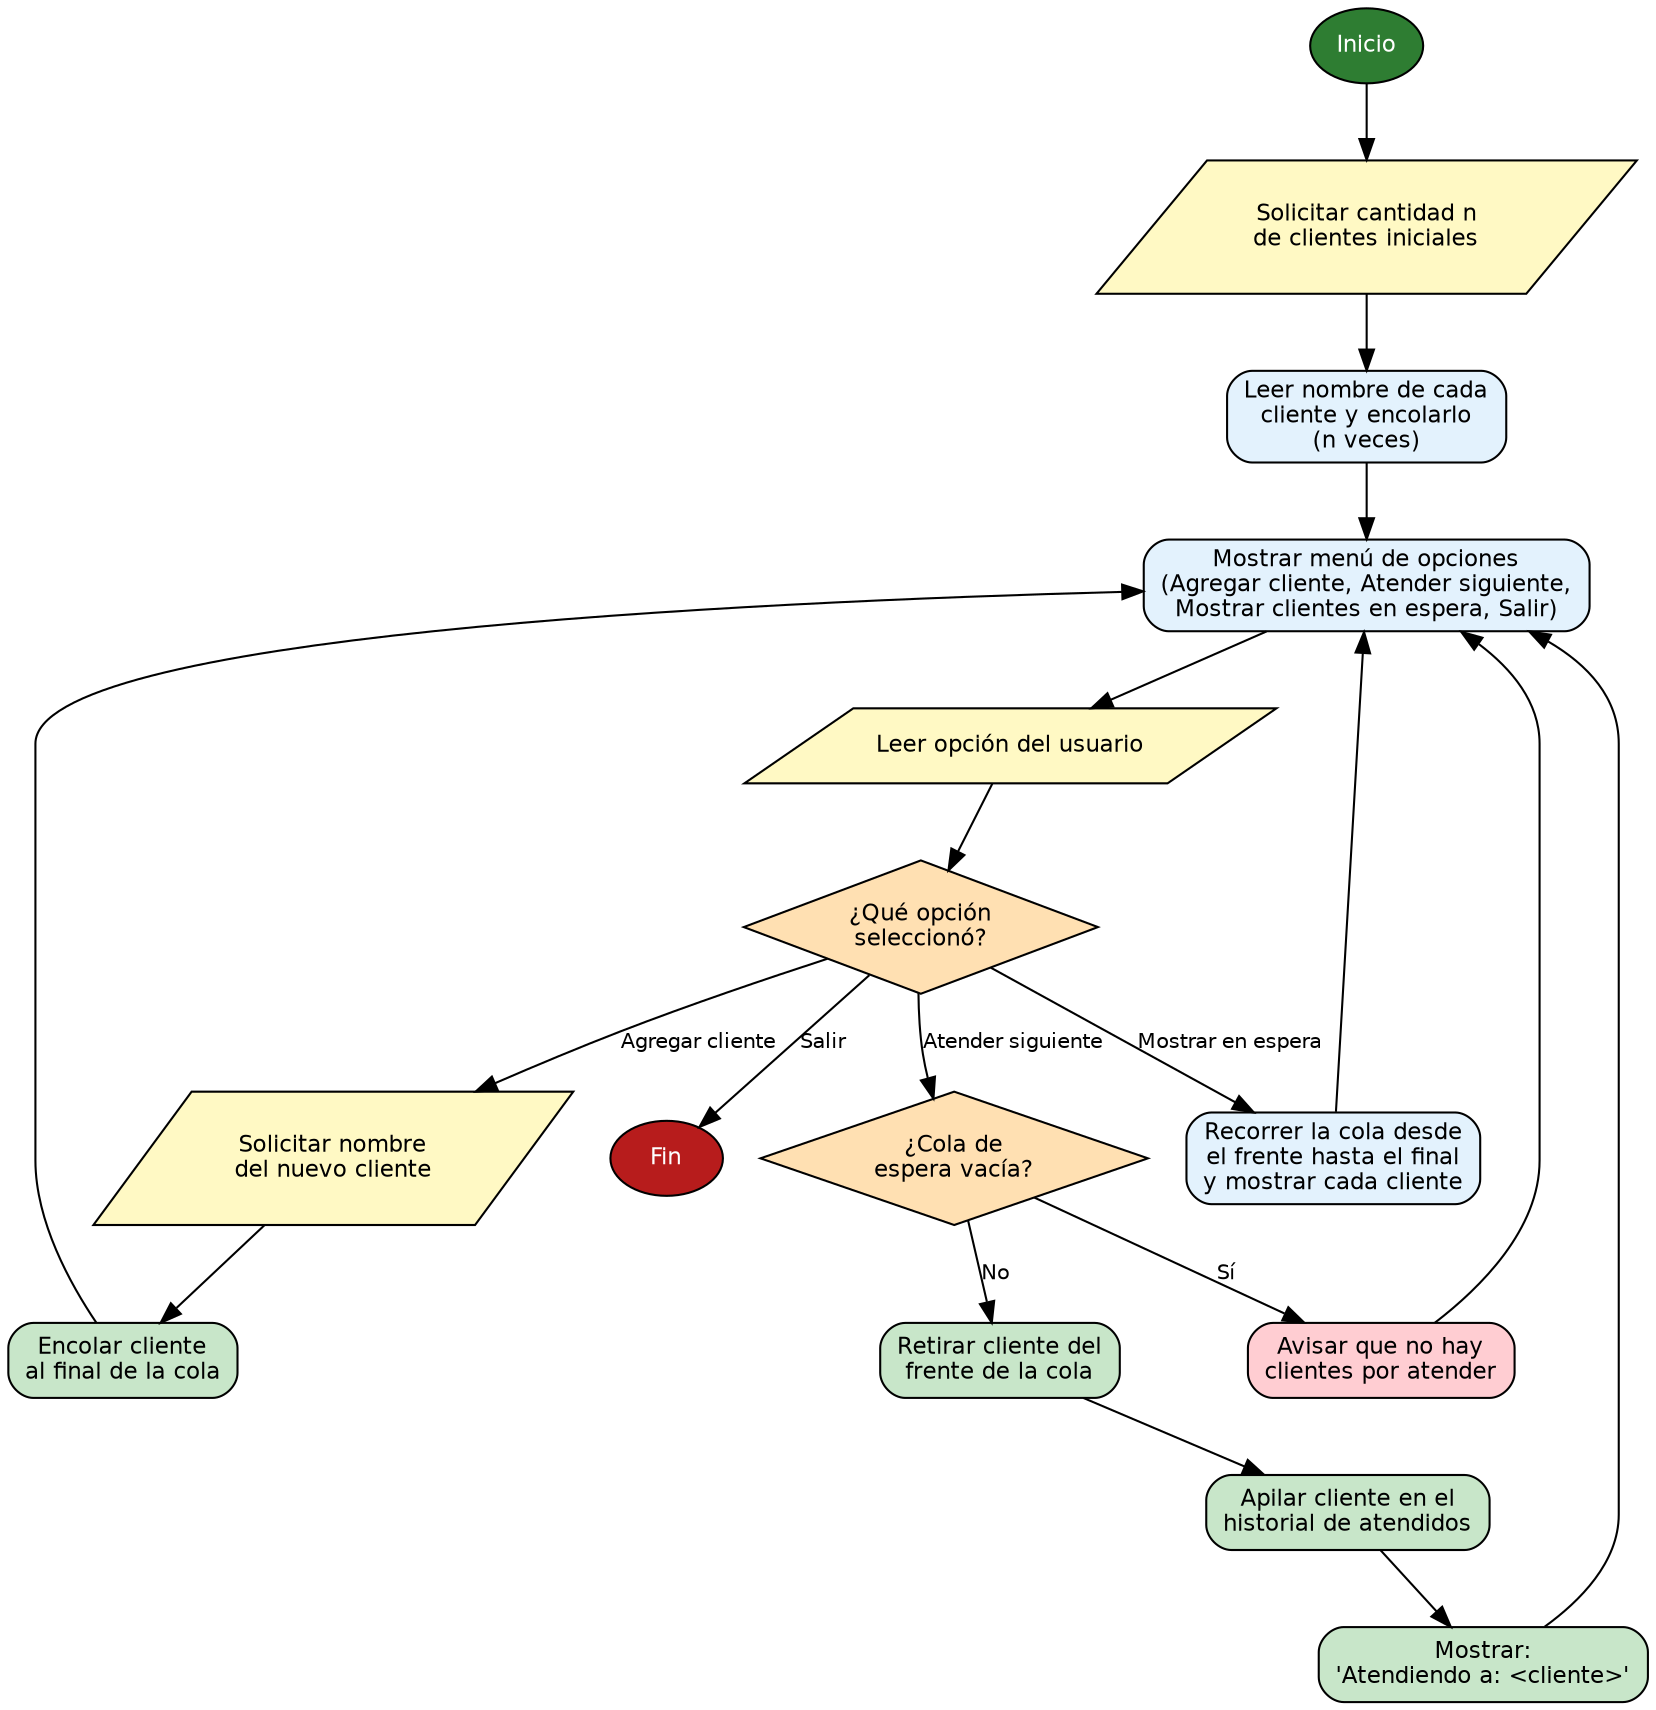

Se carga la cola con los clientes iniciales y luego un menú permite agregar clientes, atender al siguiente (validando que la cola no esté vacía) o mostrar quiénes siguen esperando.

### Pila de historial

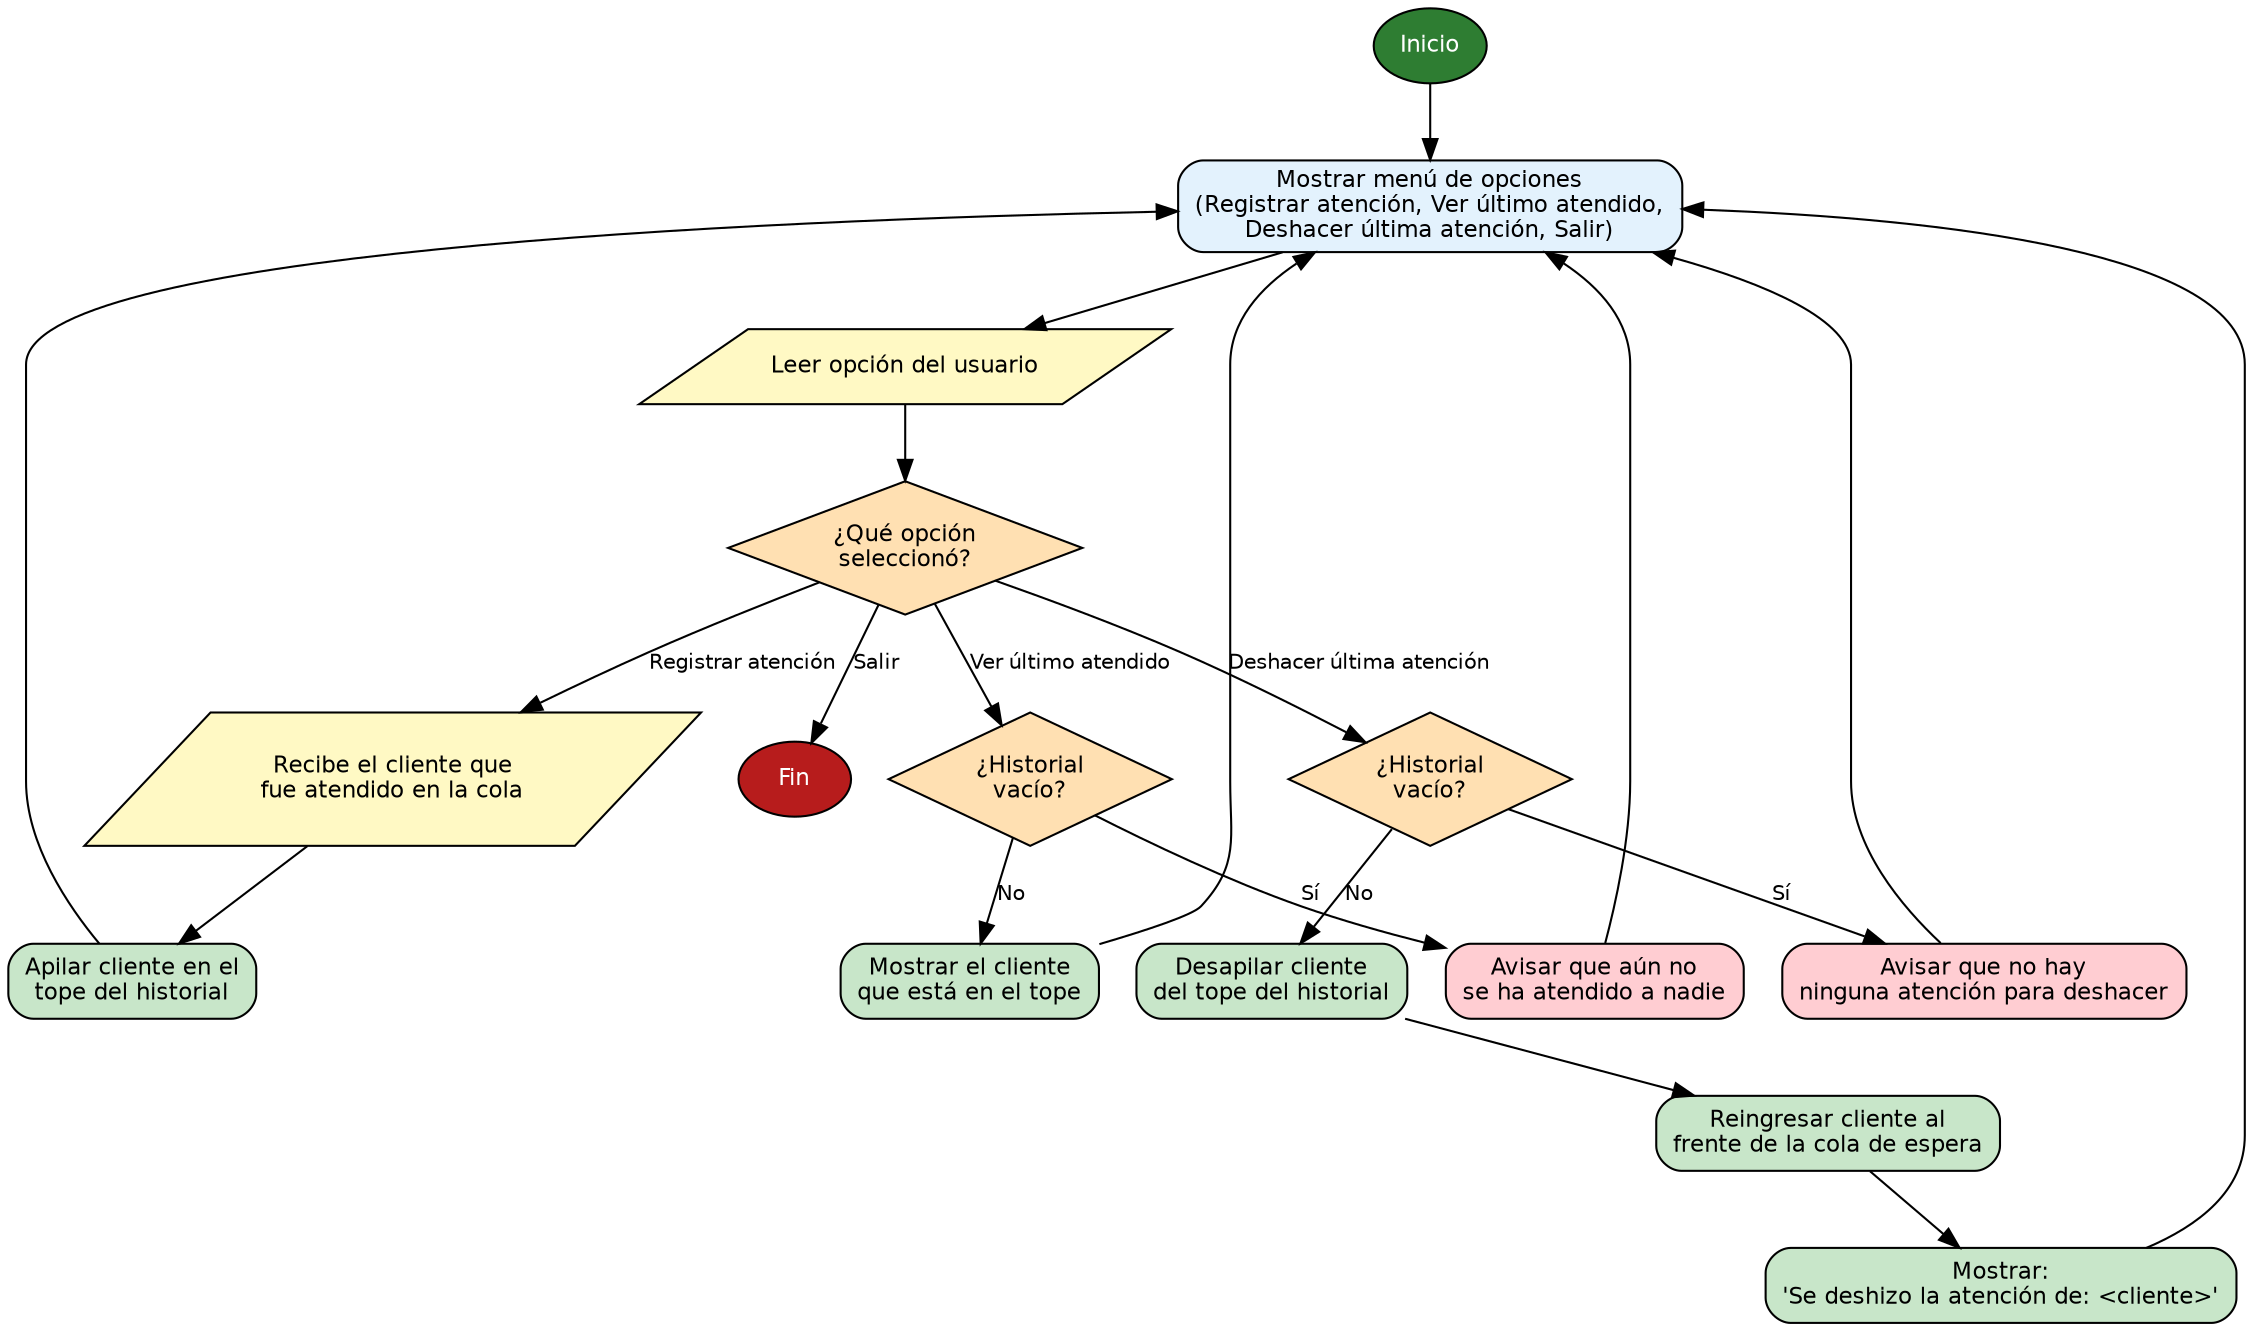

Un menú permite registrar una atención (apilar), consultar el último atendido, o deshacer la última atención — en este último caso, validando que el historial no esté vacío y regresando al cliente al frente de la cola.

### Lista de catálogo

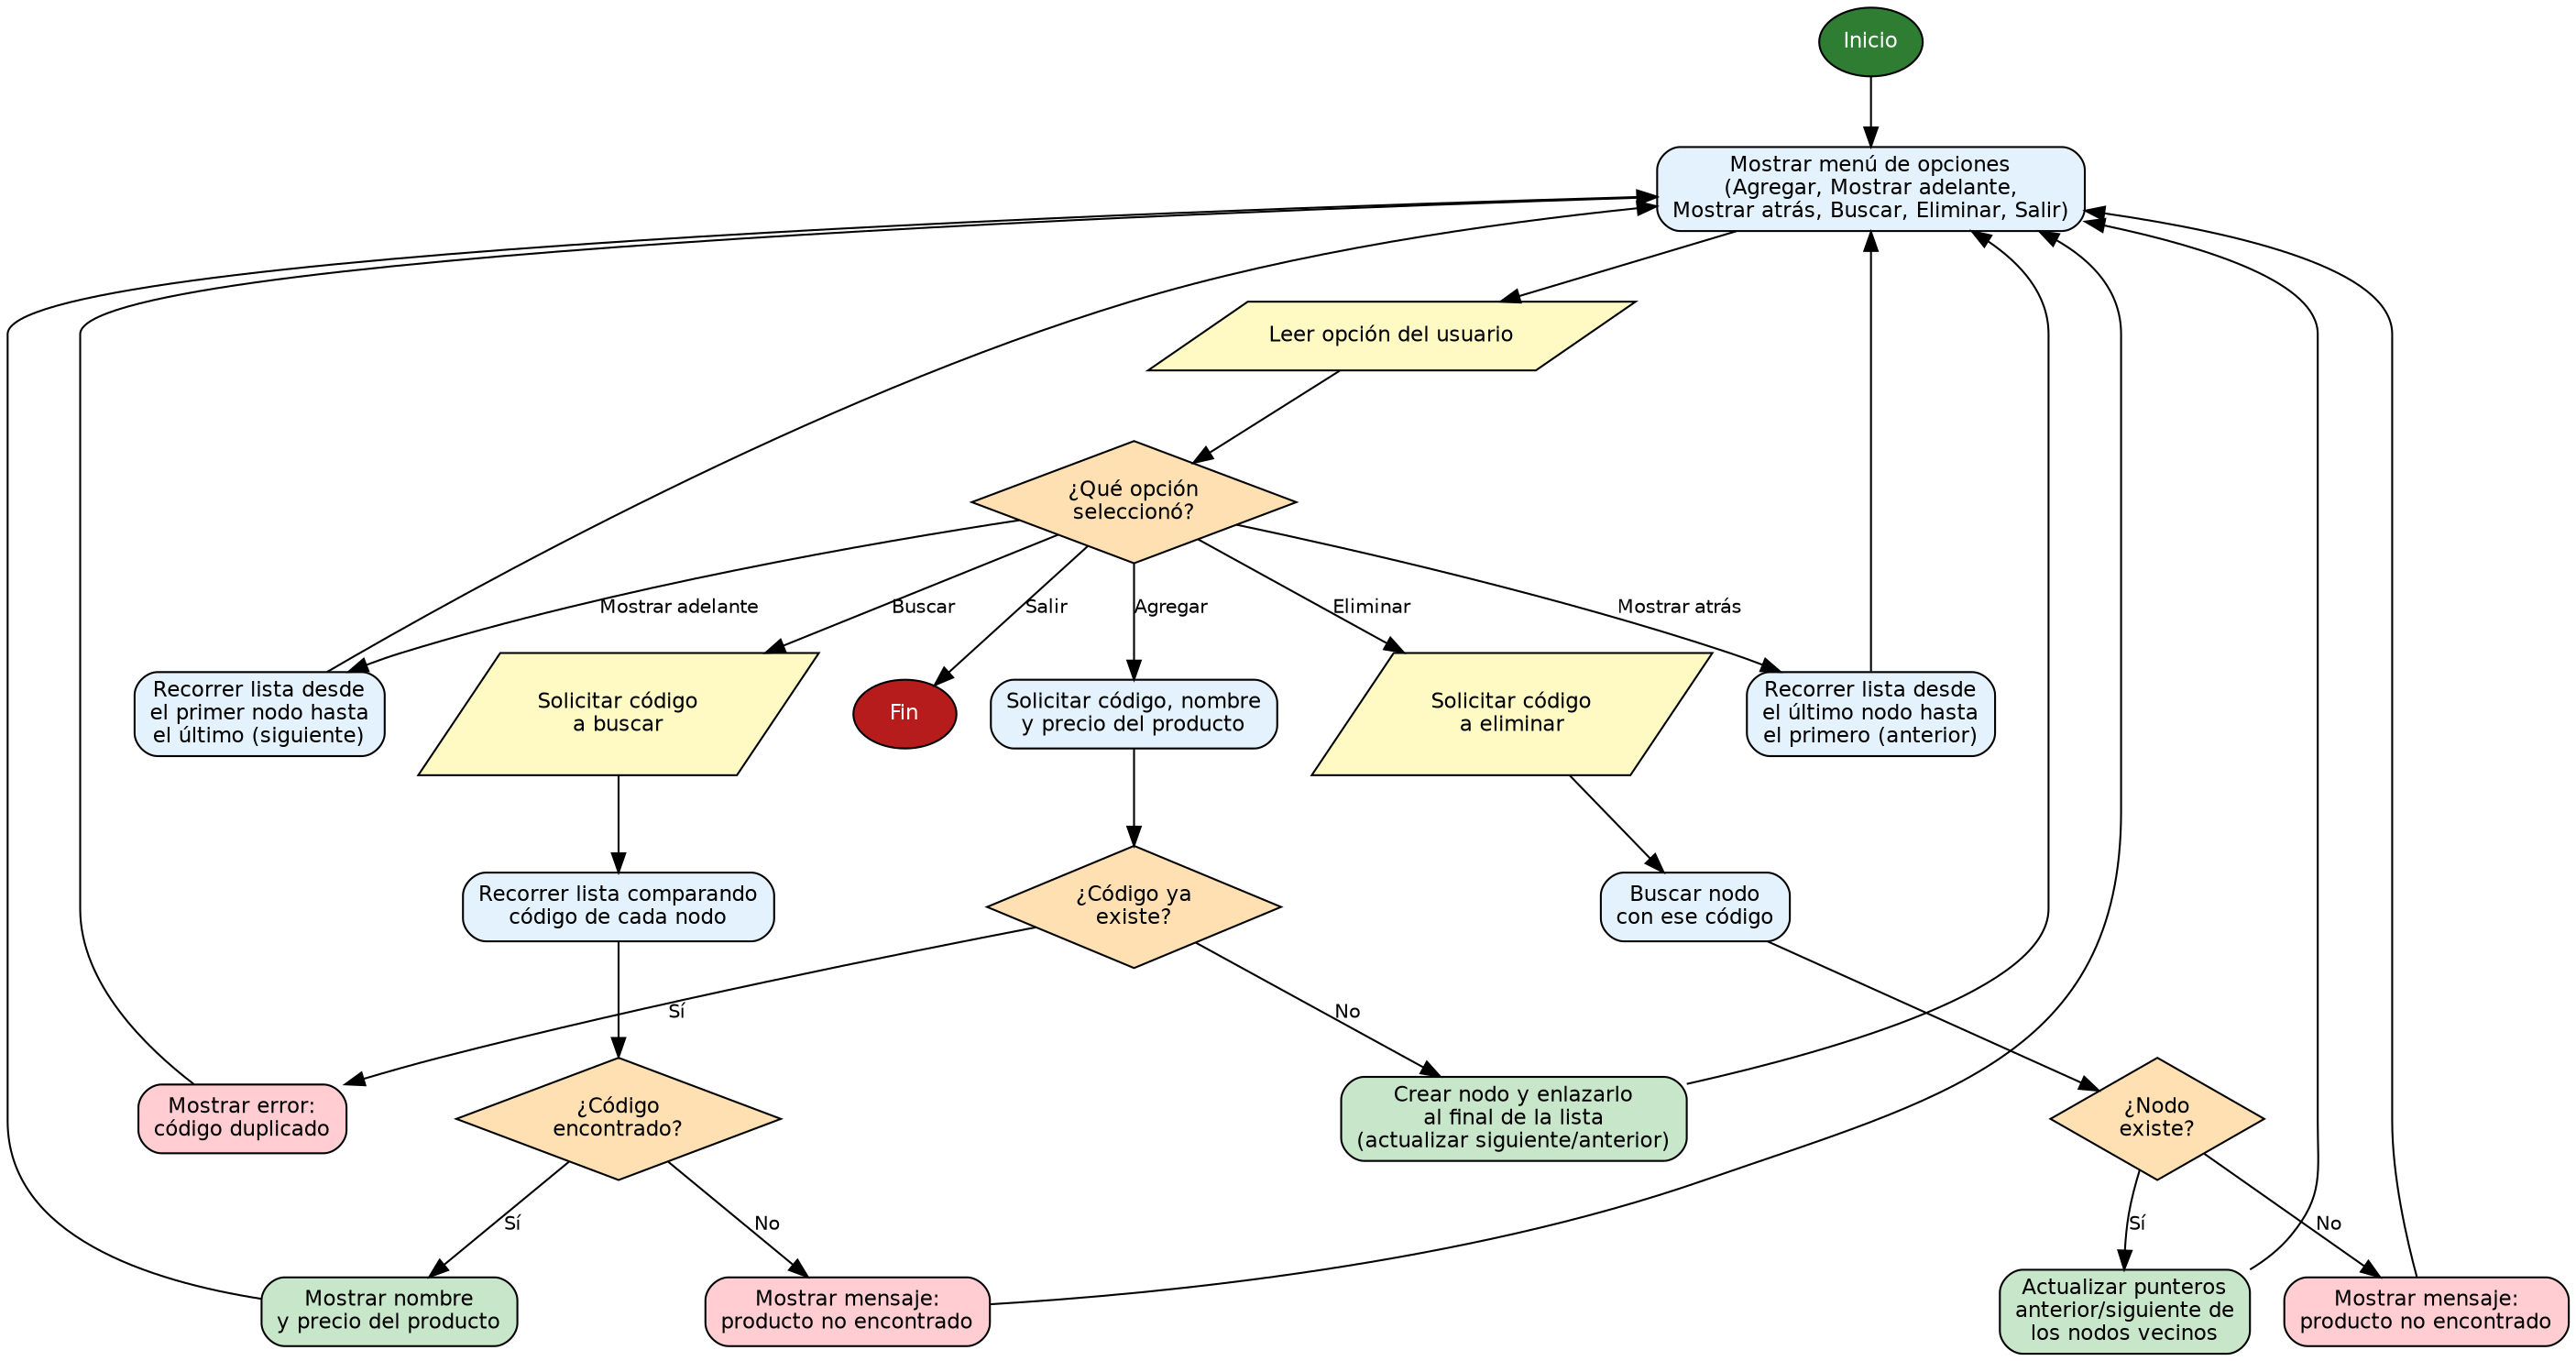

El menú permite agregar un producto (validando que el código no esté duplicado), mostrar el catálogo en ambos sentidos, buscar por código o eliminar por código.

## 5) Diagramas de secuencia **[5 pts]**

### Cola de clientes — Atender al siguiente cliente

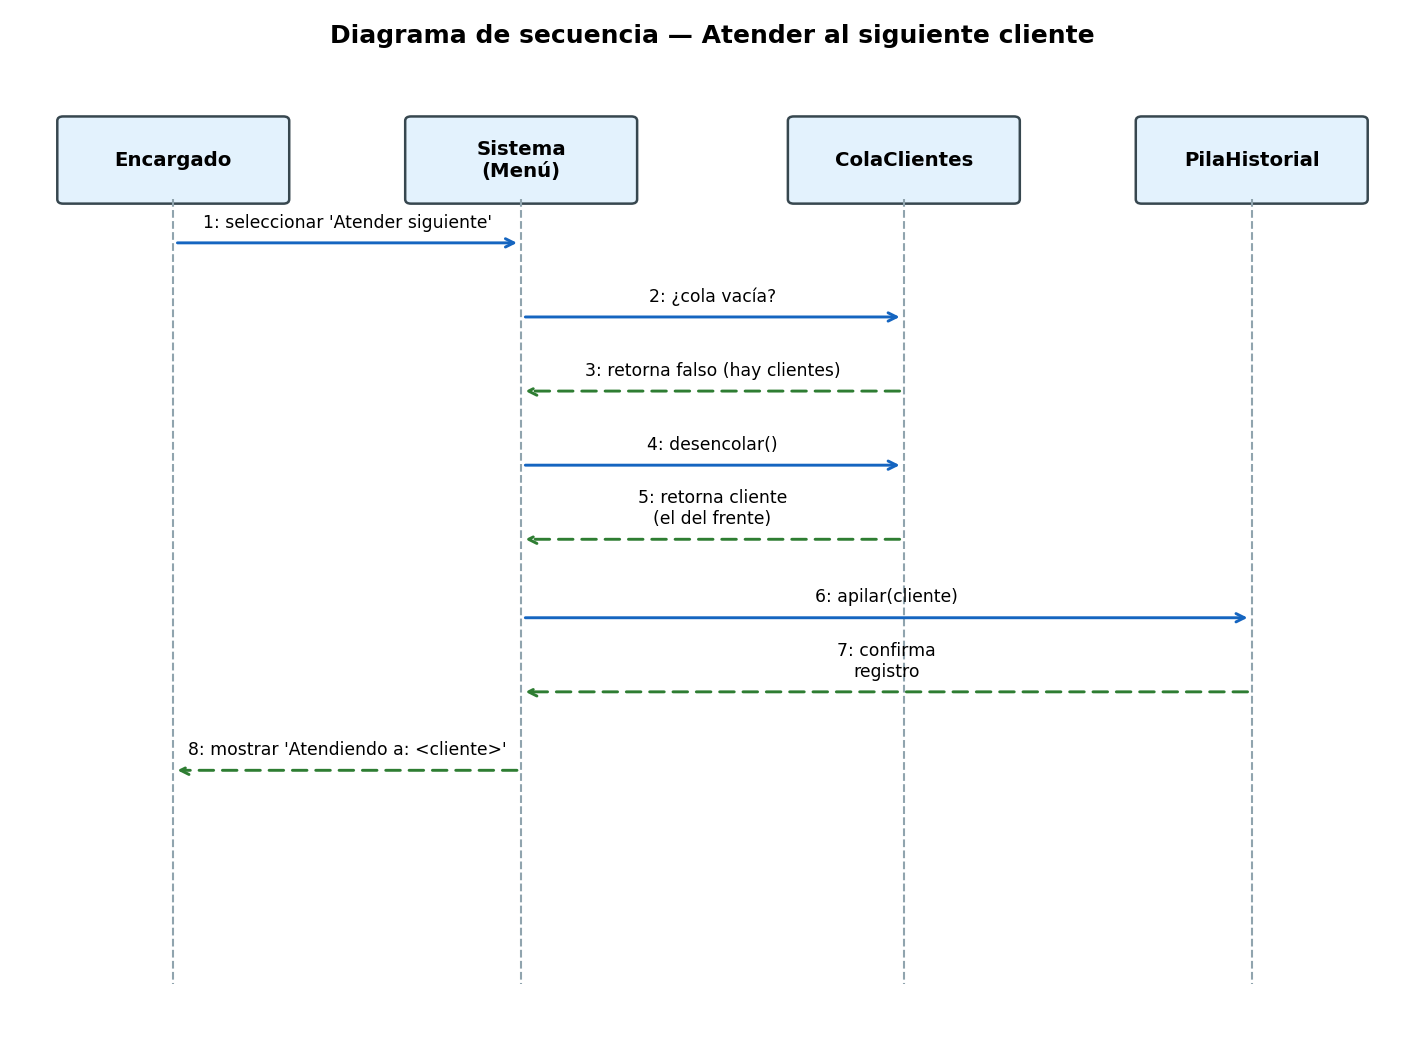

El sistema valida que la cola no esté vacía, desencola al cliente del frente y lo apila en el historial antes de mostrarlo en pantalla.

### Pila de historial — Deshacer última atención

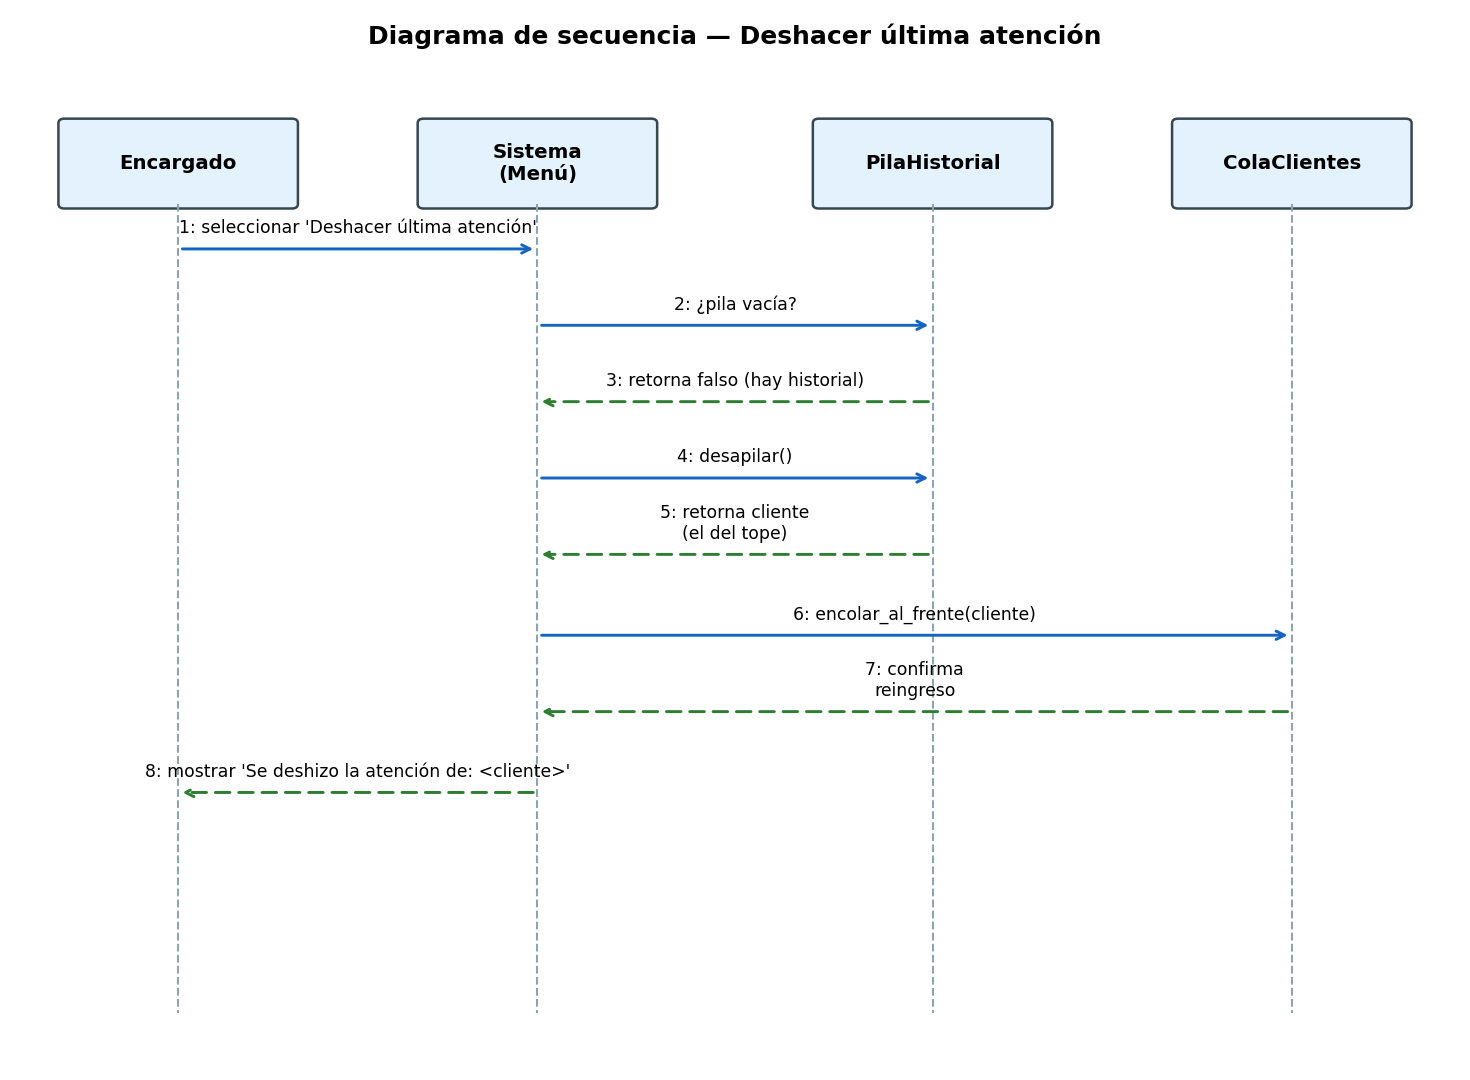

El sistema valida que el historial no esté vacío, desapila al cliente del tope y lo reingresa al frente de la cola de espera.

### Lista de catálogo — Buscar producto por código

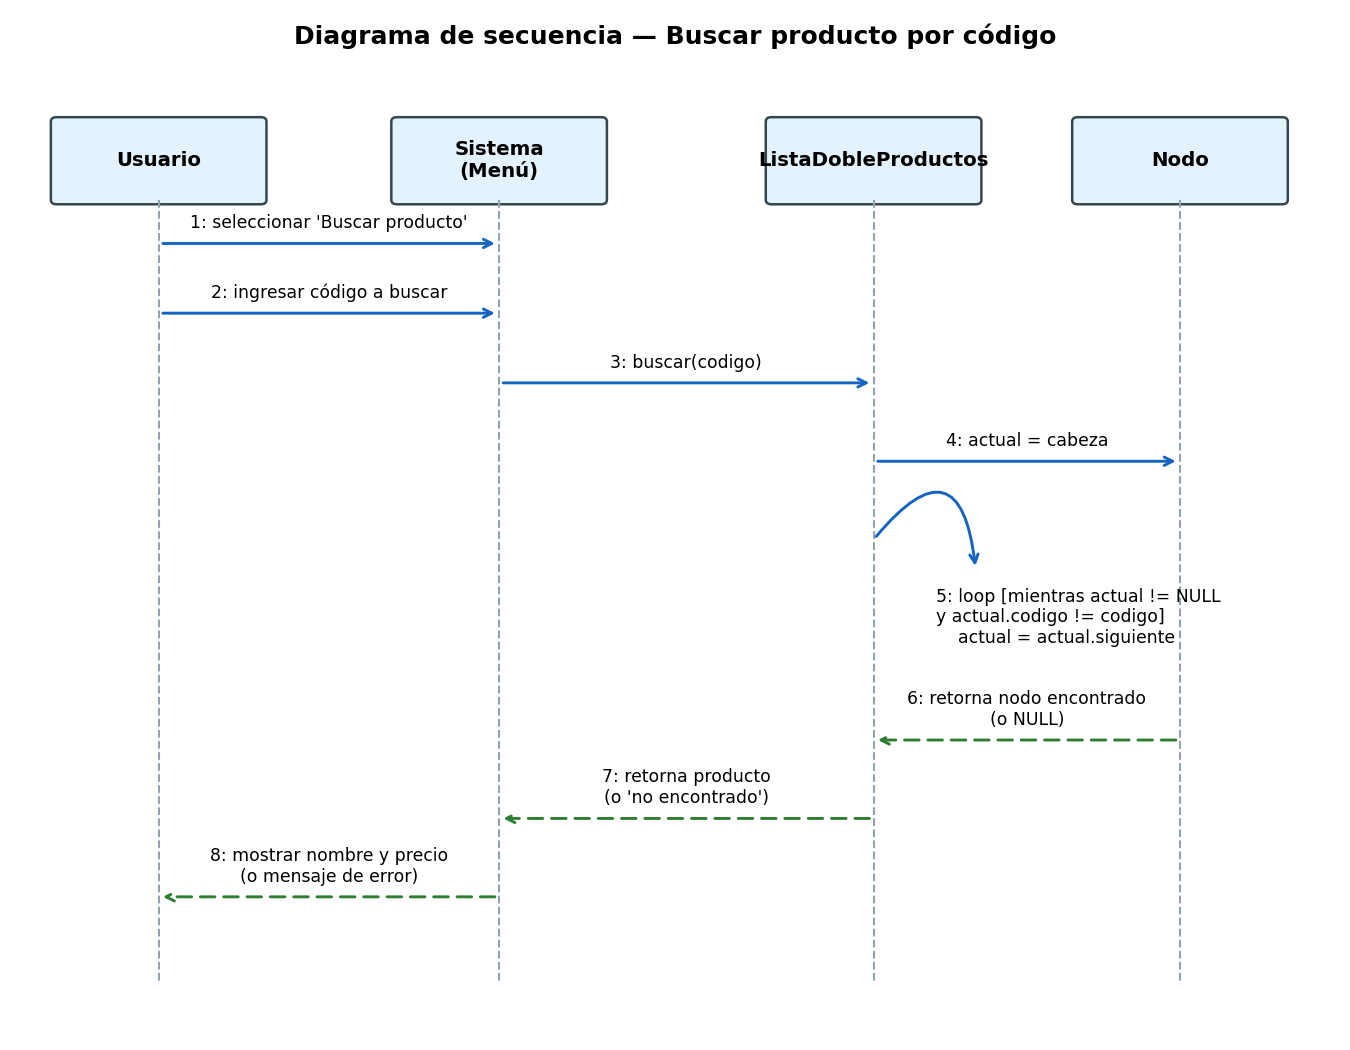

La lista recorre sus nodos desde la cabeza, comparando códigos, hasta encontrar el producto o llegar al final, y retorna el resultado al sistema.

## 6) Diagramas de casos de uso **[5 pts]**

### Cola de clientes

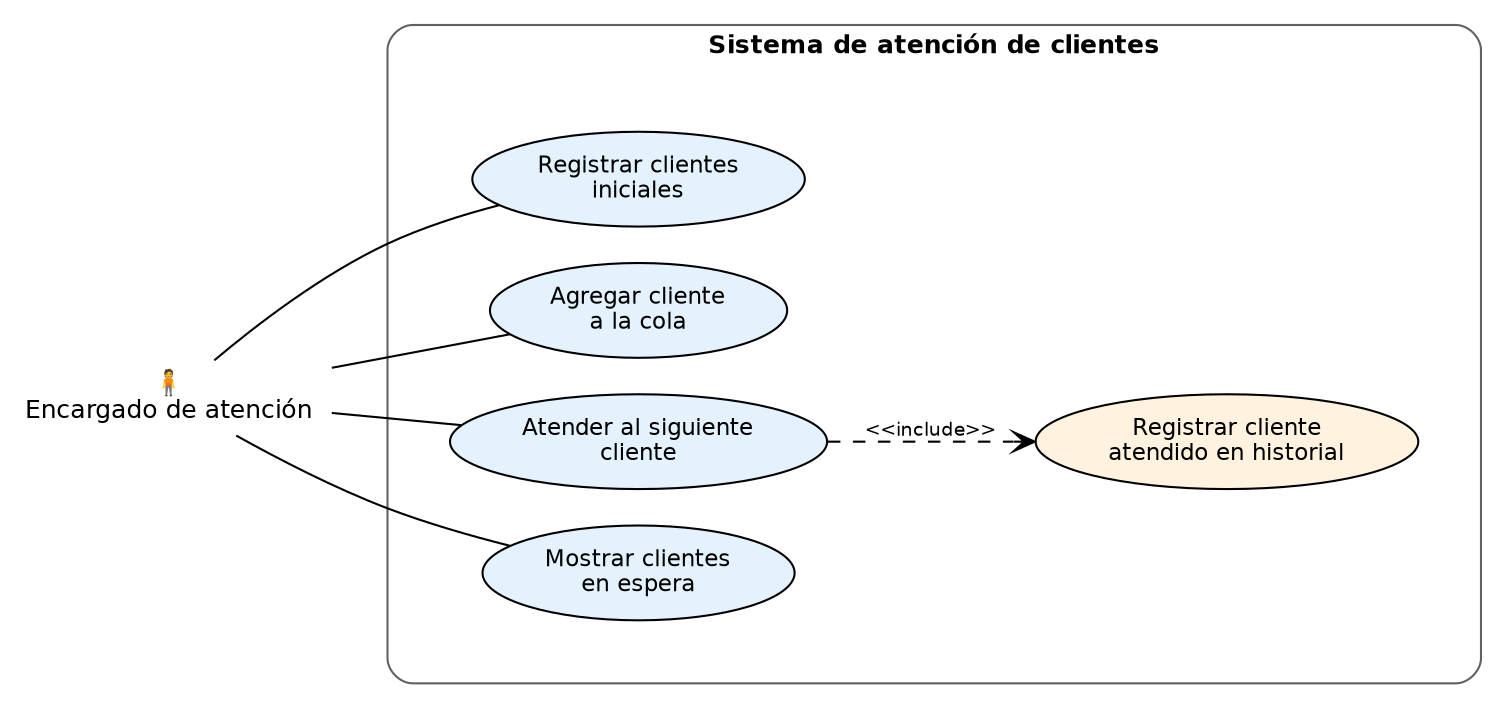

### Pila de historial

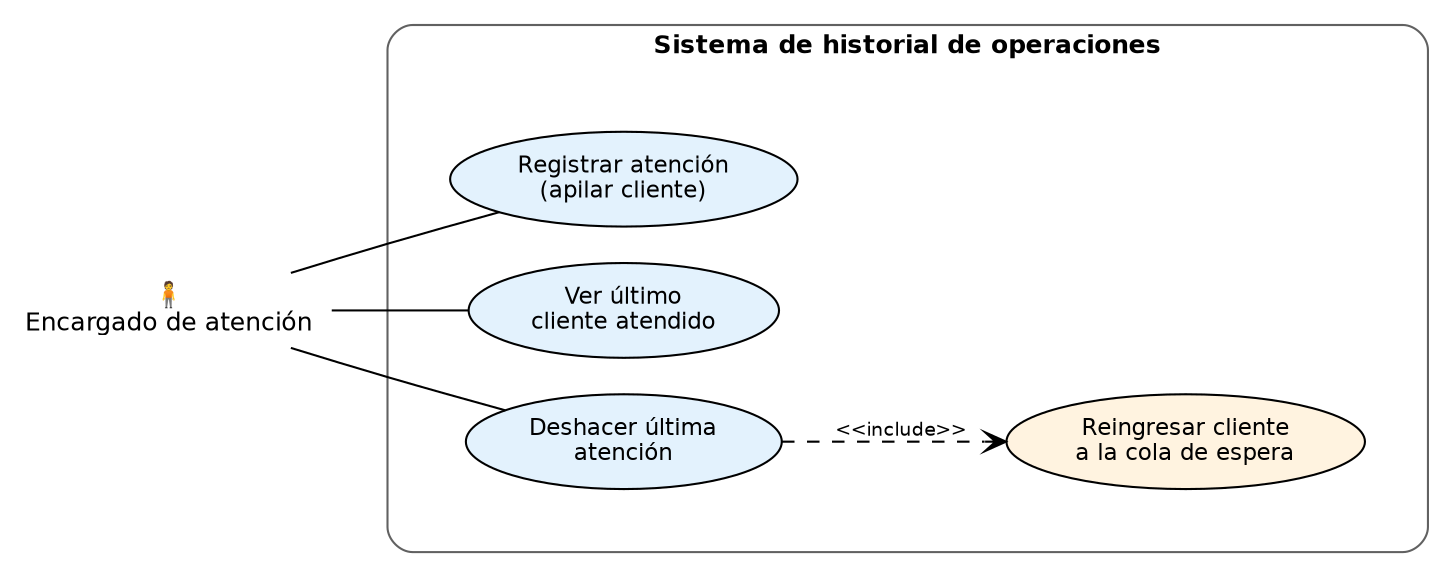

### Lista de catálogo

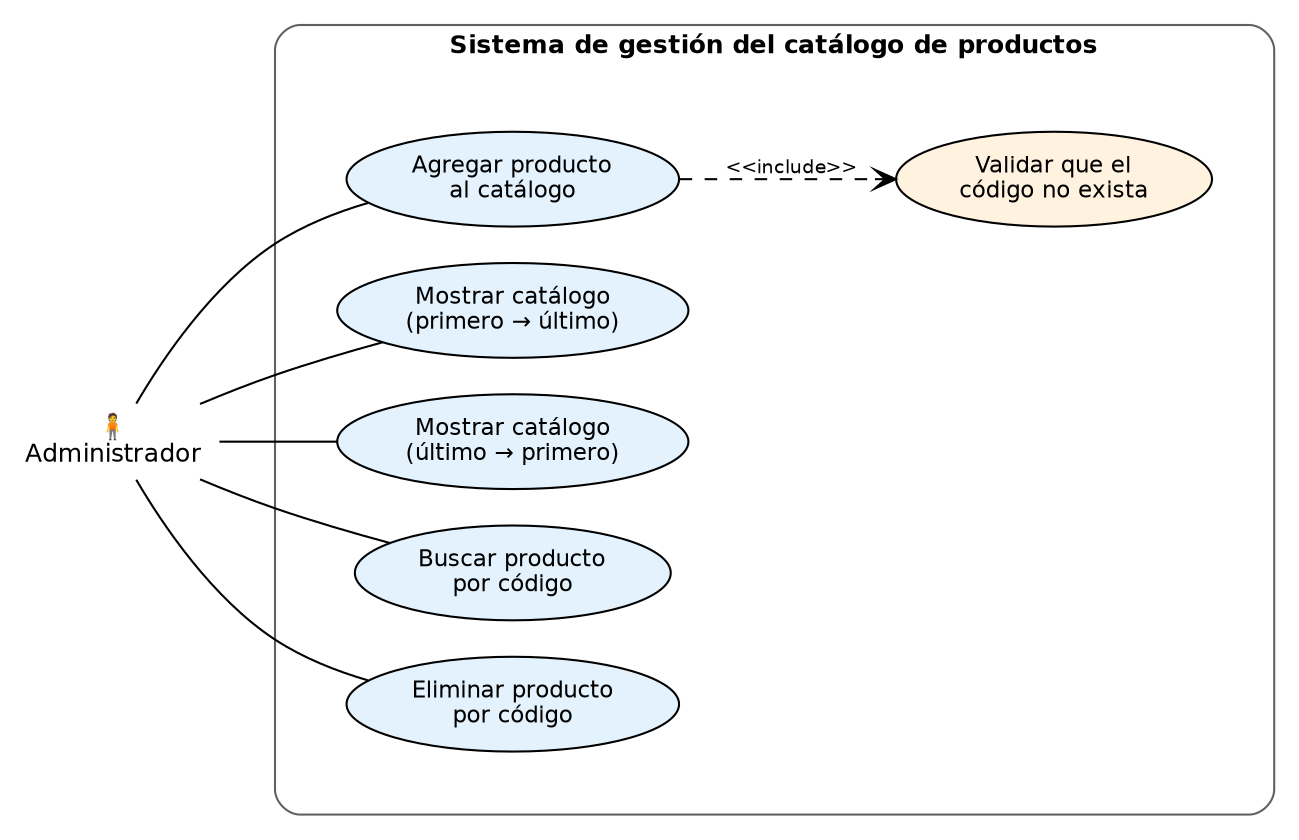

En los tres casos el actor es la persona encargada de operar la tienda (encargado de atención / administrador), quien interactúa con las operaciones propias de cada estructura. Las relaciones «include» reflejan acciones que ocurren automáticamente como parte de otra: registrar el historial al atender, reingresar a la cola al deshacer, y validar el código al agregar un producto.

## 7) Análisis de complejidad **[5 pts]**

**Justificación general:** las operaciones que trabajan sobre un extremo conocido de la estructura (frente/final de la cola, tope de la pila, cabeza/cola de la lista) son O(1), porque no requieren recorrer nada. Las operaciones que necesitan revisar el contenido — mostrar todo, buscar o eliminar por un dato que no sea el extremo — son O(n), porque en el peor caso hay que recorrer los `n` elementos.

**Tabla consolidada T(n):**

| Estructura | Operación | T(n) |
|---|---|---|
| Cola | Agregar cliente | c₁ → O(1) |
| Cola | Atender siguiente | c₂ → O(1) |
| Cola | Mostrar en espera | c₃·n + c₄ → O(n) |
| Pila | Apilar | c₅ → O(1) |
| Pila | Desapilar | c₆ → O(1) |
| Pila | Ver tope | c₇ → O(1) |
| Lista | Agregar al final | c₈ → O(1) |
| Lista | Mostrar (ambos sentidos) | c₉·n + c₁₀ → O(n) |
| Lista | Buscar por código | c₁₁·k + c₁₂, 1≤k≤n → O(n) |
| Lista | Eliminar por código | c₁₃·k + c₁₄, 1≤k≤n → O(n) |

### Cola de clientes

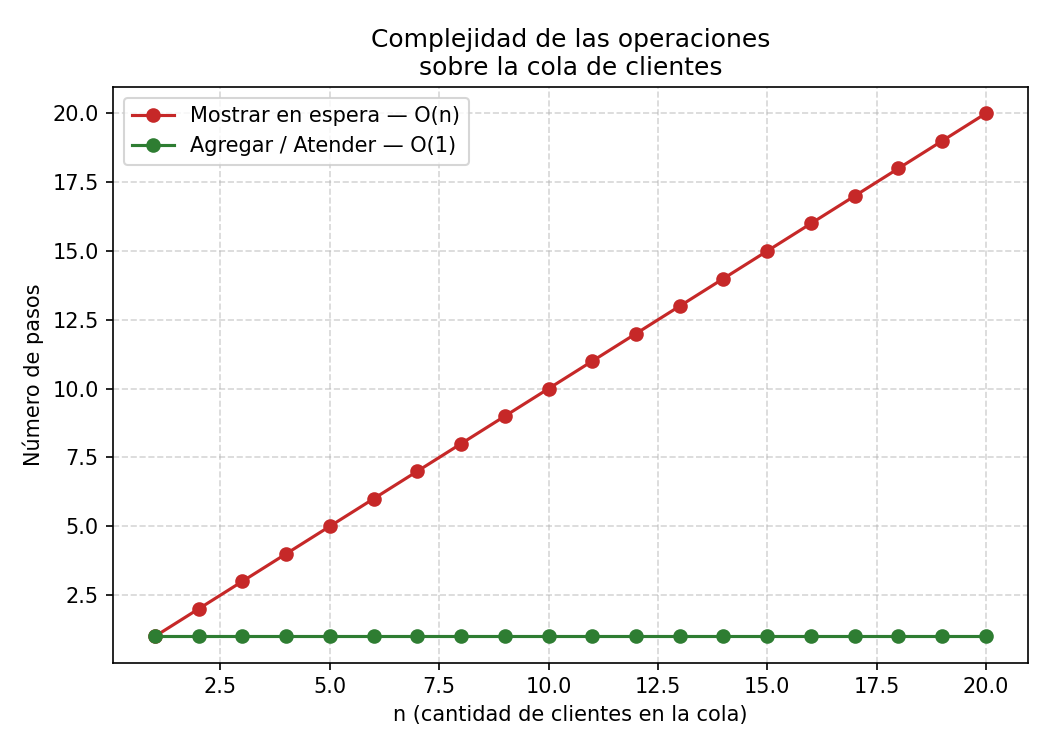

### Pila de historial

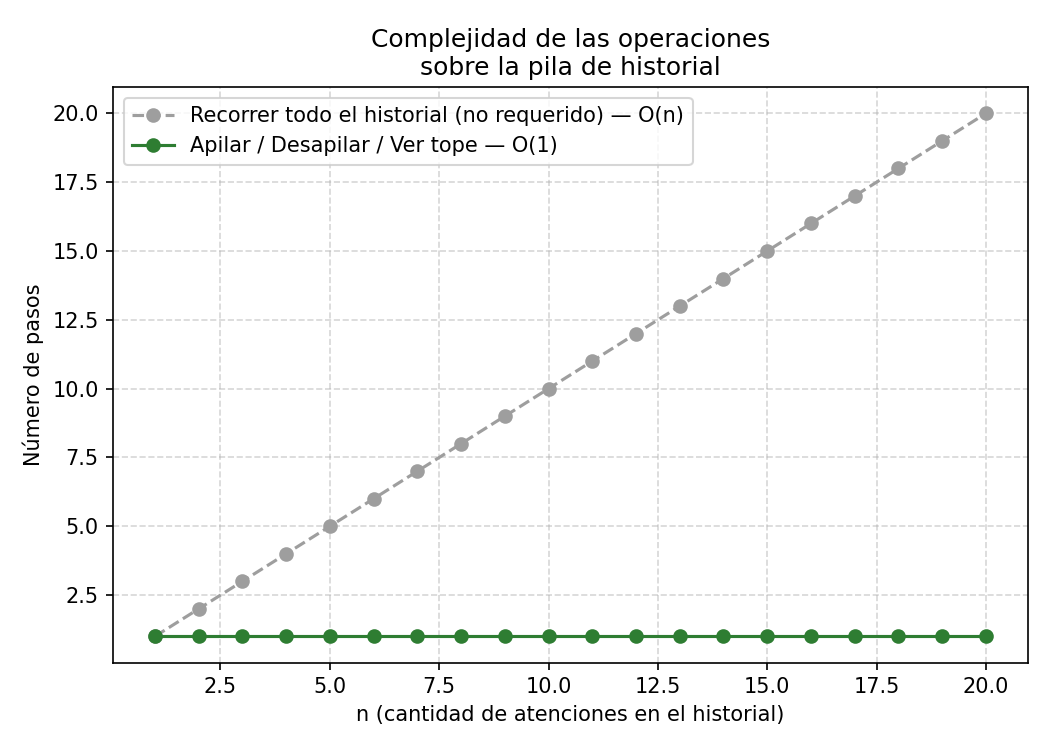

### Lista de catálogo

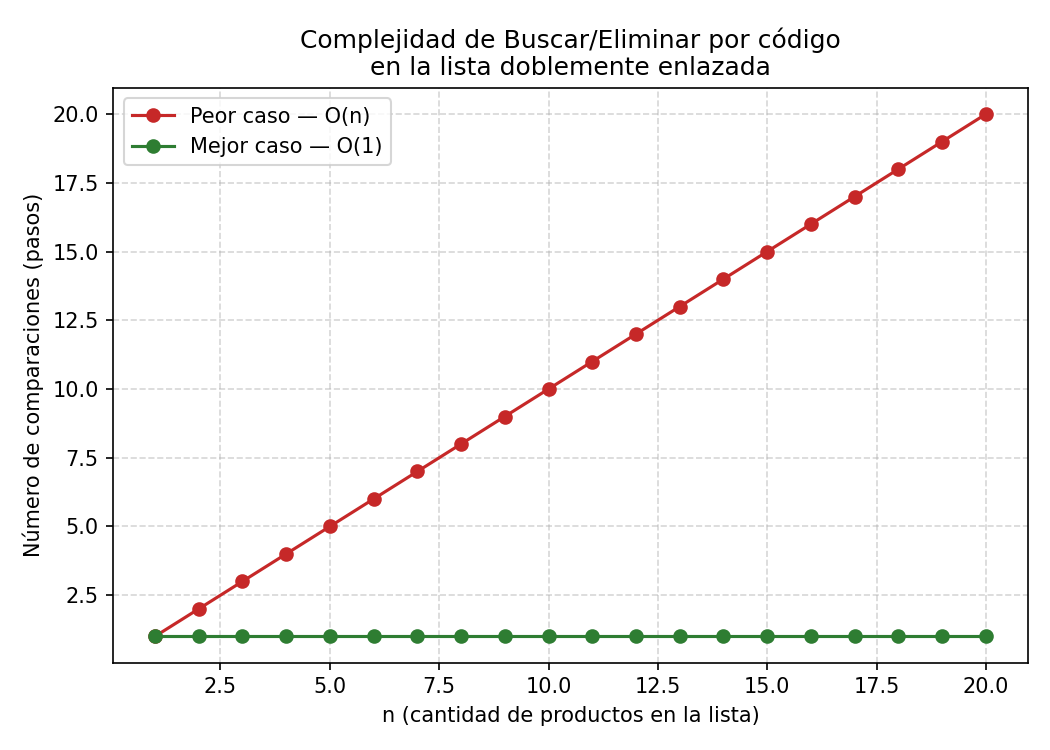

Las tres gráficas confirman el análisis teórico: las operaciones sobre extremos conocidos se mantienen constantes sin importar el tamaño de la estructura, mientras que las que requieren recorrer o buscar dentro de la estructura crecen linealmente con la cantidad de elementos almacenados.

## 8) Código funcional **[10 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [2]:
# COLA DE CLIENTES
class NodoCliente:
    def __init__(self, nombre):
        self.nombre = nombre
        self.siguiente = None


class ColaClientes:
    def __init__(self):
        self.frente = None
        self.final = None

    def encolar(self, nombre):
        nodo = NodoCliente(nombre)
        if self.frente is None:
            self.frente = nodo
            self.final = nodo
        else:
            self.final.siguiente = nodo
            self.final = nodo

    def desencolar(self):
        if self.frente is None:
            return None
        nodo = self.frente
        self.frente = self.frente.siguiente
        if self.frente is None:
            self.final = None
        return nodo.nombre

    def encolarAlFrente(self, nombre):
        nodo = NodoCliente(nombre)
        nodo.siguiente = self.frente
        self.frente = nodo
        if self.final is None:
            self.final = nodo

    def estaVacia(self):
        return self.frente is None

    def mostrarEspera(self):
        actual = self.frente
        contador = 0
        texto = ""
        while actual is not None:
            if contador == 0:
                texto = actual.nombre
            else:
                texto = texto + " -> " + actual.nombre
            actual = actual.siguiente
            contador = contador + 1
        if contador == 0:
            print("No hay clientes esperando.")
        else:
            print("Clientes esperando:", texto)


def main():
    cola = ColaClientes()

    n = int(input("¿Cuántos clientes desea registrar?: "))
    i = 0
    while i < n:
        nombreCliente = input("Ingrese el nombre del cliente " + str(i + 1) + ": ")
        cola.encolar(nombreCliente)
        i = i + 1

    opcion = ""
    while opcion != "4":
        print("\n--- MENÚ COLA DE CLIENTES ---")
        print("1. Agregar cliente")
        print("2. Atender siguiente cliente")
        print("3. Mostrar clientes en espera")
        print("4. Salir")
        opcion = input("Seleccione una opción: ")

        if opcion == "1":
            nuevo = input("Ingrese el nuevo cliente: ")
            cola.encolar(nuevo)

        elif opcion == "2":
            if cola.estaVacia():
                print("No hay clientes por atender.")
            else:
                atendido = cola.desencolar()
                print("Atendiendo a:", atendido)

        elif opcion == "3":
            cola.mostrarEspera()

        elif opcion == "4":
            print("Cerrando el sistema de atención...")

        else:
            print("Opción no válida.")


if __name__ == "__main__":

    main()

In [3]:

#PILA DE HISTORIAL

class NodoHistorial:
    def __init__(self, nombre):
        self.nombre = nombre
        self.siguiente = None


class PilaHistorial:
    def __init__(self):
        self.tope = None

    def apilar(self, nombre):
        nodo = NodoHistorial(nombre)
        nodo.siguiente = self.tope
        self.tope = nodo

    def desapilar(self):
        if self.tope is None:
            return None
        nodo = self.tope
        self.tope = self.tope.siguiente
        return nodo.nombre

    def verUltimo(self):
        if self.tope is None:
            return None
        return self.tope.nombre

    def estaVacia(self):
        return self.tope is None


def main():
    historial = PilaHistorial()

    opcion = ""
    while opcion != "4":
        print("\n--- MENÚ HISTORIAL (PILA) ---")
        print("1. Registrar atención")
        print("2. Ver último atendido")
        print("3. Deshacer última atención")
        print("4. Salir")
        opcion = input("Seleccione una opción: ")

        if opcion == "1":
            nombreCliente = input("Nombre del cliente atendido: ")
            historial.apilar(nombreCliente)
            print("Atención registrada.")

        elif opcion == "2":
            if historial.estaVacia():
                print("Aún no se ha atendido a nadie.")
            else:
                print("Último atendido:", historial.verUltimo())

        elif opcion == "3":
            if historial.estaVacia():
                print("No hay ninguna atención para deshacer.")
            else:
                deshecho = historial.desapilar()
                print("Se deshizo la atención de:", deshecho)

        elif opcion == "4":
            print("Cerrando el sistema de historial...")

        else:
            print("Opción no válida.")


if __name__ == "__main__":
    main()

In [4]:
#Lista doble enlazada

class NodoProducto:
    def __init__(self, codigo, nombre, precio):
        self.codigo = codigo
        self.nombre = nombre
        self.precio = precio
        self.anterior = None
        self.siguiente = None


class ListaProductos:
    def __init__(self):
        self.cabeza = None
        self.cola = None

    def agregar(self, codigo, nombre, precio):
        if self.buscar(codigo) is not None:
            print("Ya existe un producto con el código", codigo)
            return
        nodo = NodoProducto(codigo, nombre, precio)
        if self.cabeza is None:
            self.cabeza = nodo
            self.cola = nodo
        else:
            nodo.anterior = self.cola
            self.cola.siguiente = nodo
            self.cola = nodo

    def mostrarAdelante(self):
        actual = self.cabeza
        texto = "NULL"
        while actual is not None:
            texto = texto + " <-> " + actual.nombre
            actual = actual.siguiente
        texto = texto + " -> NULL"
        print(texto)

    def mostrarAtras(self):
        actual = self.cola
        texto = "NULL"
        while actual is not None:
            texto = texto + " <-> " + actual.nombre
            actual = actual.anterior
        texto = texto + " -> NULL"
        print(texto)

    def buscar(self, codigo):
        actual = self.cabeza
        while actual is not None:
            if actual.codigo == codigo:
                return actual
            actual = actual.siguiente
        return None

    def eliminar(self, codigo):
        nodo = self.buscar(codigo)
        if nodo is None:
            print("No existe un producto con el código", codigo)
            return
        if nodo.anterior is not None:
            nodo.anterior.siguiente = nodo.siguiente
        else:
            self.cabeza = nodo.siguiente
        if nodo.siguiente is not None:
            nodo.siguiente.anterior = nodo.anterior
        else:
            self.cola = nodo.anterior
        print("Producto", nodo.nombre, "eliminado.")


def main():
    catalogo = ListaProductos()

    opcion = ""
    while opcion != "6":
        print("\n--- MENÚ CATÁLOGO (LISTA DOBLE) ---")
        print("1. Agregar producto")
        print("2. Mostrar catálogo (adelante)")
        print("3. Mostrar catálogo (atrás)")
        print("4. Buscar producto")
        print("5. Eliminar producto")
        print("6. Salir")
        opcion = input("Seleccione una opción: ")

        if opcion == "1":
            codigo = input("Código del producto: ")
            nombreProducto = input("Nombre del producto: ")
            precio = float(input("Precio del producto: "))
            catalogo.agregar(codigo, nombreProducto, precio)

        elif opcion == "2":
            catalogo.mostrarAdelante()

        elif opcion == "3":
            catalogo.mostrarAtras()

        elif opcion == "4":
            codigoBuscar = input("Ingrese el código que desea buscar: ")
            resultado = catalogo.buscar(codigoBuscar)
            if resultado is None:
                print("Producto no encontrado.")
            else:
                print(resultado.nombre, "-", resultado.precio)

        elif opcion == "5":
            codigoEliminar = input("Ingrese el código que desea eliminar: ")
            catalogo.eliminar(codigoEliminar)

        elif opcion == "6":
            print("Cerrando el sistema de catálogo...")

        else:
            print("Opción no válida.")


if __name__ == "__main__":
    main()

## 9) pruebas **[15 pts]**

In [5]:
# ===============================================================
#  MOTOR DE PRUEBAS AUTOMATICAS
# ===============================================================
# Requisito: ejecutar antes las celdas de la seccion 8 para que queden
# definidas ColaClientes, PilaHistorial y ListaProductos (puede detener
# el menu interactivo con el boton de stop: las clases ya quedan cargadas).
#
# Cada caso de prueba tiene:
#   - ENTRADA  = lista de operaciones sobre el sistema de la tienda
#   - SALIDA   = lista de respuestas que debe producir el sistema
#
# Operaciones soportadas:
#   ("ENCOLAR", nombre)             -> "OK"
#   ("ATENDER",)                    -> cliente atendido | "VACIA"
#   ("ESPERA",)                     -> "Ana -> Luis"    | "VACIA"
#   ("ULTIMO",)                     -> ultimo atendido  | "VACIA"
#   ("DESHACER",)                   -> cliente devuelto al frente | "VACIA"
#   ("AGREGAR", cod, nombre, precio)-> "OK" | "DUPLICADO"
#   ("BUSCAR", cod)                 -> nombre | "NO_ENCONTRADO"
#   ("ELIMINAR", cod)               -> "OK"   | "NO_ENCONTRADO"
#   ("CATALOGO",)                   -> "A <-> B" | "VACIO"
#   ("CATALOGO_REV",)               -> "B <-> A" | "VACIO"

import io
from contextlib import redirect_stdout


class Tienda:
    """Integra las tres estructuras para poder probarlas de forma automatica."""

    def __init__(self):
        self.cola = ColaClientes()
        self.historial = PilaHistorial()
        self.catalogo = ListaProductos()

    def _espera(self):
        actual, partes = self.cola.frente, []
        while actual is not None:
            partes.append(actual.nombre)
            actual = actual.siguiente
        return " -> ".join(partes) if partes else "VACIA"

    def _listar(self, reverso=False):
        actual = self.catalogo.cola if reverso else self.catalogo.cabeza
        partes = []
        while actual is not None:
            partes.append(actual.nombre)
            actual = actual.anterior if reverso else actual.siguiente
        return " <-> ".join(partes) if partes else "VACIO"

    def ejecutar(self, op):
        accion = op[0]
        if accion == "ENCOLAR":
            self.cola.encolar(op[1]); return "OK"
        if accion == "ATENDER":
            if self.cola.estaVacia(): return "VACIA"
            atendido = self.cola.desencolar()
            self.historial.apilar(atendido)
            return atendido
        if accion == "ESPERA":
            return self._espera()
        if accion == "ULTIMO":
            return "VACIA" if self.historial.estaVacia() else self.historial.verUltimo()
        if accion == "DESHACER":
            if self.historial.estaVacia(): return "VACIA"
            cliente = self.historial.desapilar()
            self.cola.encolarAlFrente(cliente)
            return cliente
        if accion == "AGREGAR":
            if self.catalogo.buscar(op[1]) is not None: return "DUPLICADO"
            self.catalogo.agregar(op[1], op[2], op[3]); return "OK"
        if accion == "BUSCAR":
            nodo = self.catalogo.buscar(op[1])
            return "NO_ENCONTRADO" if nodo is None else nodo.nombre
        if accion == "ELIMINAR":
            if self.catalogo.buscar(op[1]) is None: return "NO_ENCONTRADO"
            self.catalogo.eliminar(op[1]); return "OK"
        if accion == "CATALOGO":
            return self._listar()
        if accion == "CATALOGO_REV":
            return self._listar(reverso=True)
        raise ValueError("Operacion desconocida: " + accion)


def resolver(operaciones):
    tienda = Tienda()
    salidas = []
    with redirect_stdout(io.StringIO()):
        for op in operaciones:
            salidas.append(tienda.ejecutar(op))
    return salidas


def test(entrada, salida_esperada, descripcion=""):
    # Si la entrada es una lista de operaciones se simula el sistema completo;
    # si es un valor simple se compara directamente (formato base de la plantilla).
    if isinstance(entrada, list):
        obtenida = resolver(entrada)
    else:
        obtenida = entrada
    assert obtenida == salida_esperada, (
        f"FALLO {descripcion}\n  entrada:  {entrada}\n"
        f"  esperada: {salida_esperada}\n  obtenida: {obtenida}")
    print(f"Paso caso de prueba {descripcion} -> {obtenida}")




## Pruebas de enunciado

¿Qué va aquí?

Casos de prueba proporcionados por el enunciado.

Entrada usada.

Salida esperada.

Salida obtenida.

In [6]:
# CASOS DE PRUEBA DEL ENUNCIADO
test([("ENCOLAR","Ana"),("ENCOLAR","Luis"),("ENCOLAR","Sofia"),
      ("ATENDER",),("ESPERA",)],
     ["OK","OK","OK","Ana","Luis -> Sofia"], "Cola FIFO")

test([("ENCOLAR","Ana"),("ENCOLAR","Luis"),("ATENDER",),("ATENDER",),
      ("ULTIMO",),("DESHACER",),("ESPERA",),("ULTIMO",)],
     ["OK","OK","Ana","Luis","Luis","Luis","Luis","Ana"], "Pila LIFO + deshacer")

test([("AGREGAR","P1","Arroz",4500.0),("AGREGAR","P2","Leche",3200.0),
      ("AGREGAR","P3","Pan",2000.0),("CATALOGO",),("CATALOGO_REV",),
      ("BUSCAR","P2"),("ELIMINAR","P2"),("CATALOGO",)],
     ["OK","OK","OK","Arroz <-> Leche <-> Pan","Pan <-> Leche <-> Arroz",
      "Leche","OK","Arroz <-> Pan"], "Lista doble")


Paso caso de prueba Cola FIFO -> ['OK', 'OK', 'OK', 'Ana', 'Luis -> Sofia']
Paso caso de prueba Pila LIFO + deshacer -> ['OK', 'OK', 'Ana', 'Luis', 'Luis', 'Luis', 'Luis', 'Ana']
Paso caso de prueba Lista doble -> ['OK', 'OK', 'OK', 'Arroz <-> Leche <-> Pan', 'Pan <-> Leche <-> Arroz', 'Leche', 'OK', 'Arroz <-> Pan']


## Pruebas propias
¿Qué va aquí?

Casos creados por usted.

Casos tomados de [UDebug](https://www.udebug.com/) (si aplica).


In [7]:
# CASOS DE PRUEBA PROPIOS (casos borde y de integracion)
test([("ATENDER",),("ESPERA",),("ULTIMO",),("DESHACER",)],
     ["VACIA","VACIA","VACIA","VACIA"], "Estructuras vacias")
test([("ENCOLAR","Ana"),("ATENDER",),("DESHACER",),("ATENDER",),("ESPERA",)],
     ["OK","Ana","Ana","Ana","VACIA"], "Deshacer devuelve al frente")
test([("AGREGAR","P1","Arroz",4500.0),("AGREGAR","P1","Arroz importado",5000.0),
      ("CATALOGO",)], ["OK","DUPLICADO","Arroz"], "Codigo duplicado")
test([("AGREGAR","P1","A",1.0),("AGREGAR","P2","B",2.0),("AGREGAR","P3","C",3.0),
      ("ELIMINAR","P1"),("CATALOGO",),("ELIMINAR","P3"),("CATALOGO_REV",),
      ("ELIMINAR","P9")],
     ["OK","OK","OK","OK","B <-> C","OK","B","NO_ENCONTRADO"], "Eliminar extremos")
test([("BUSCAR","P1"),("AGREGAR","P1","Arroz",4500.0),("BUSCAR","P1"),
      ("ELIMINAR","P1"),("BUSCAR","P1"),("CATALOGO",)],
     ["NO_ENCONTRADO","OK","Arroz","OK","NO_ENCONTRADO","VACIO"], "Busqueda")


Paso caso de prueba Estructuras vacias -> ['VACIA', 'VACIA', 'VACIA', 'VACIA']
Paso caso de prueba Deshacer devuelve al frente -> ['OK', 'Ana', 'Ana', 'Ana', 'VACIA']
Paso caso de prueba Codigo duplicado -> ['OK', 'DUPLICADO', 'Arroz']
Paso caso de prueba Eliminar extremos -> ['OK', 'OK', 'OK', 'OK', 'B <-> C', 'OK', 'B', 'NO_ENCONTRADO']
Paso caso de prueba Busqueda -> ['NO_ENCONTRADO', 'OK', 'Arroz', 'OK', 'NO_ENCONTRADO', 'VACIO']


## Pruebas de Desempeño
Qué va aquí?

Medición empírica del tiempo de ejecución.

Gráfica de comportamiento.

Relación entre la gráfica obtenida y el análisis de complejidad teórico.

#### Código base para benchmarking



n      cola O(1) (ms)   lista O(n) (ms)
1      0.000228         0.000056
201    0.000214         0.003702
401    0.000213         0.008119
601    0.000211         0.012507
801    0.000321         0.016541
1001   0.000217         0.019428
1201   0.000217         0.023730
1401   0.000214         0.028094
1601   0.000212         0.031769
1801   0.000209         0.035636


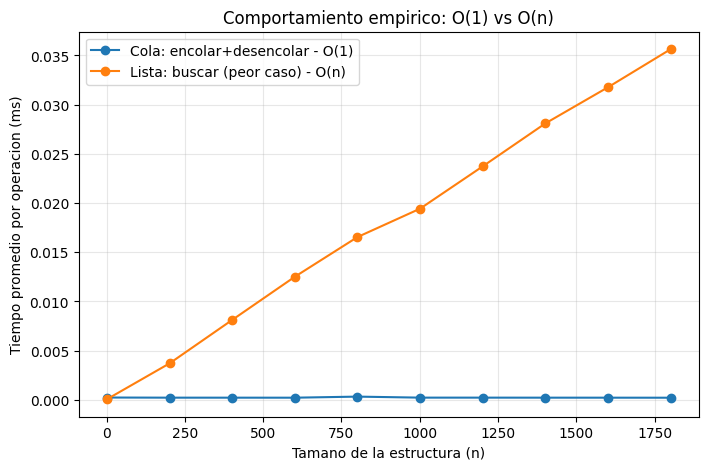

In [8]:
# ===============================================================
#  PRUEBAS DE DESEMPENO
# ===============================================================
# Se comparan dos operaciones representativas:
#   - Cola: encolar + desencolar  (teoricamente O(1))
#   - Lista: buscar codigo inexistente, peor caso (teoricamente O(n))
# Cada medicion se repite REPS veces y se promedia para reducir el ruido.

import time

def construir_cola(size):
    c = ColaClientes()
    for i in range(size):
        c.encolar("C" + str(i))
    return c


def construir_catalogo(size):
    lista = ListaProductos()
    for i in range(size):
        nodo = NodoProducto("P" + str(i), "Prod" + str(i), float(i))
        if lista.cabeza is None:
            lista.cabeza = nodo; lista.cola = nodo
        else:
            nodo.anterior = lista.cola; lista.cola.siguiente = nodo; lista.cola = nodo
    return lista


REPS = 200

def bench_cola(n, step=1):
    res = []
    for size in range(1, n, step):
        cola = construir_cola(size)
        ti = time.perf_counter()
        for _ in range(REPS):
            cola.encolar("X"); cola.desencolar()
        tf = time.perf_counter()
        res.append((size, (tf - ti) * 1000 / REPS))
    return res


def bench_lista(n, step=1):
    res = []
    for size in range(1, n, step):
        lista = construir_catalogo(size)
        ti = time.perf_counter()
        for _ in range(REPS):
            lista.buscar("NO_EXISTE")
        tf = time.perf_counter()
        res.append((size, (tf - ti) * 1000 / REPS))
    return res


# === CODIGO PARA DIBUJAR ===
def dibujar(series, dimensiones=(8, 5)):
    import matplotlib.pyplot as plt
    plt.figure(figsize=dimensiones)
    for etiqueta, datos in series.items():
        plt.plot([s for s, t in datos], [t for s, t in datos], marker="o", label=etiqueta)
    plt.xlabel("Tamano de la estructura (n)")
    plt.ylabel("Tiempo promedio por operacion (ms)")
    plt.title("Comportamiento empirico: O(1) vs O(n)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# === LLAMADO ===
N = 2001
PASO = 200

tiempos_cola = bench_cola(N, step=PASO)
print()
tiempos_lista = bench_lista(N, step=PASO)
print()

print("n      cola O(1) (ms)   lista O(n) (ms)")
for (n1, t1), (n2, t2) in zip(tiempos_cola, tiempos_lista):
    print(f"{n1:<6} {t1:<16.6f} {t2:.6f}")

dibujar({"Cola: encolar+desencolar - O(1)": tiempos_cola,
         "Lista: buscar (peor caso) - O(n)": tiempos_lista})


### Relacion entre la grafica y el analisis teorico

- **Cola (encolar + desencolar):** la curva se mantiene practicamente horizontal al aumentar `n`. El tiempo no depende del tamano de la cola porque solo se manipulan los punteros `frente` y `final`, lo que confirma el **O(1)** de la tabla de la seccion 7. Las pequenas oscilaciones corresponden a ruido de medicion del sistema operativo, no a crecimiento.
- **Lista doble (buscar en el peor caso):** la curva crece de forma aproximadamente lineal con `n`. Al buscar un codigo que no existe hay que recorrer los `n` nodos, por lo que duplicar el tamano del catalogo duplica el tiempo: esto confirma el **O(n)** teorico.
- La misma conclusion aplica a las demas operaciones de recorrido (`mostrarEspera`, `mostrarAdelante`, `mostrarAtras`, `eliminar`), que dependen de `buscar` o recorren toda la estructura, y a `verUltimo`/`apilar`/`desapilar` de la pila, que son O(1) por trabajar solo sobre el tope.

**Conclusion:** el comportamiento empirico coincide con el analisis de complejidad de la seccion 7: constante para las operaciones sobre un extremo conocido y lineal para las que deben recorrer el contenido.
